In [ ]:
from IPython.display import Image
from utils import plot_combine_cross_genre_results, sonify_track

# Results and Discussion
---
This notebook shows the result plots for each methods and discussion of each results. 

## Baseline results

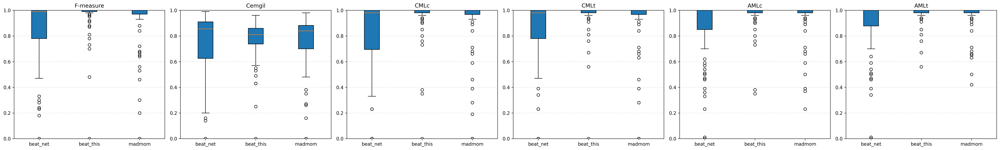

In [2]:
box_plot_dir = "./results/box_plots/"
Image(box_plot_dir + "baseline_results_boxplots.png")

From the baseline boxplot, we can see that *Beat This!* is showing the consistent results overall.
* *Beat This!* is showing less outliers and low variances.

* *Beat This!* and *Madmom* are showing similar median values overall, but *Madmom* has more outliers and high variances.

* From Continuity, *Beat This!* has less outlier and steady variance.

Overall, *Beat This!* and *Madmom* are showing similar performance, however, *Beat This!* is slightly more steady.  

## Single Genre Tempo Changes results

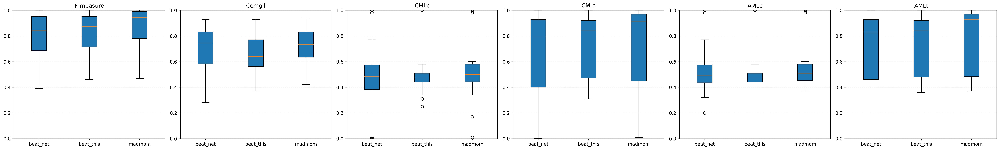

In [3]:
Image(box_plot_dir + "single_genre_results_boxplots.png")

This plots are showing the result of Single Genre Tempo Changes. Data is created by concatenating two different tempo within same genre (pop).
* *Madmom* is showing the best results from F-Measure and Cemgil. However, from the continuity scores, *Beat This!* is more stable as we can see that the result data is more concentrated in CMLc and AMLc (the box size is small). 

* From CMLt, even considering the disconnection of the continuity (because sometimes the models predict in half-time or double-time), the *Beat This!* is showing the best stability. 

## Linear Tempo Changes Results

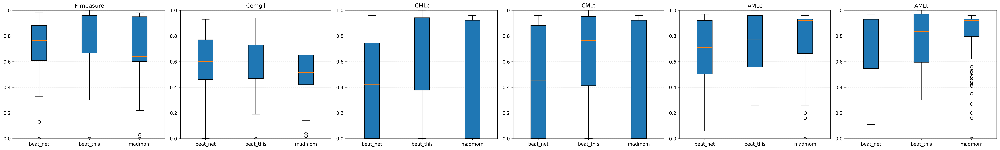

In [4]:
Image(box_plot_dir + "linear_stretch_results_boxplots.png")

From this box plot, we can see that *Beat This!* has the highest F-Measure and Cemgil score while *Madmom* is showing the lowest scores.
* From the CMLc and CMLt, all models are showing wide spread of results, and this is because the models predict the tempo in double time when the tempo gradually slow down. (Please see the beat plots below)

* Looking at the CMLc and AMLc in linear-stretch method, CMLc for *Madmom* is worst while AMLc performs best. This indicates that the *Madmom* often predicts the beats in double-time or half-time compared to the ground truth. We assume that this happens because as the audio slows down to 0.5x speed (half tempo), *Madmom* continues to track at the original faster tempo, resulting in double-time predictions relative to the slowed-down audio. Future works should include different tempo change rate.

* Additionally, *Beat This!* stops predicting when the audio is empty (from ~42 seconds), but other models (*BeatNet* and *mamdom*) keeps predicting the beat on the empty audio. (Please see the beat plots below)

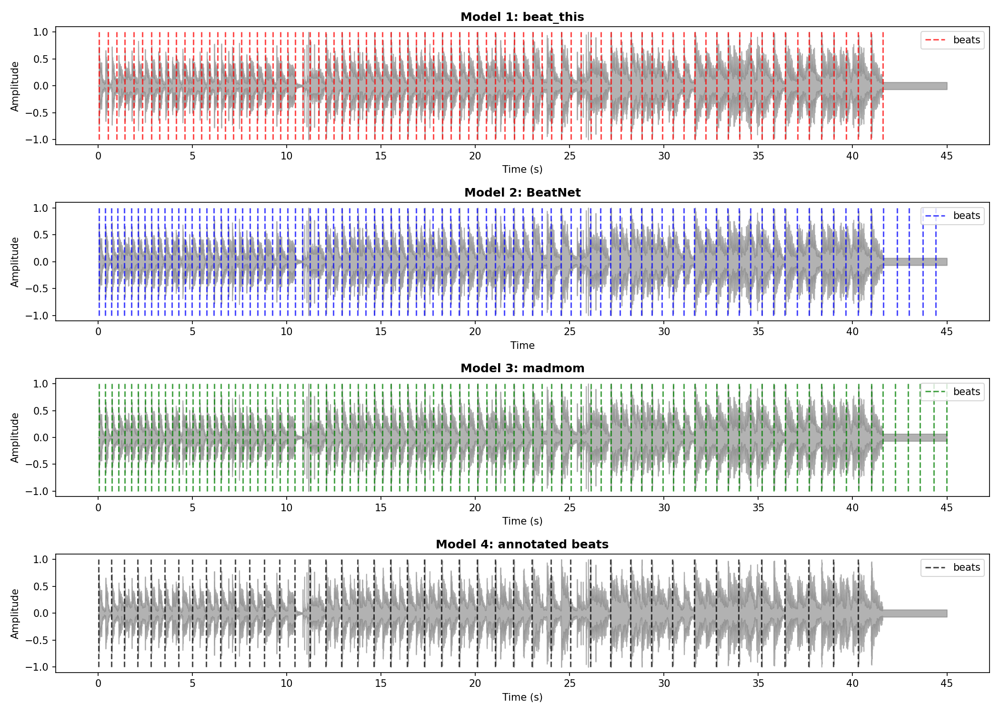

In [5]:
# Example of one data from linear-stretch
beat_plot_dir = "./results/beat_plots/"
Image(beat_plot_dir + "linear_stretch/RM-P014_bpm88_0.5x_beat_comparison.png", width=1000, height=1000)

## Cross Genre Tempo Changes Results

In [6]:
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
plot_combine_cross_genre_results(genres)

Saved combined plot to: ./results/box_plots/cross_genre_combined_results.png


In [7]:
Image(box_plot_dir + "cross_genre_combined_results.png")

Overall, *Madmom* is mostly showing the highest score in F-measure and Cemgil score. 

* Most of the genres are showing similar scores in F-measure, Cemgil and continuity, as well as showing similar results as single genre tempo changes. 

* However, from the box plots in "classical" and "jazz" genre, it shows relatively lower scores than other genres. We assume that this is because the characteristic of each genres. For example, usually from the classical and jazz genre where the audio doesn't have obvious tempo, such as rubato, the model can't predict the beats well. 

# Overall Discussion

**Looking at the F-measures and Cemgil scores, *Madmom* consistently performs better than other two except the linear stretch methods. *Beat This!* is second.**

* *Beat This!* performs best in Linear Stretch, where *Madmom* is the worst. 

* For linear stretch data, CMLc may not fully reflect model performance because the models occasionally predict the beats in half-time or double-time relative to the changing tempo. The AMLc metric (which allows for double/half-time) provides more appropriate evaluation in this situation. 


**In terms of genre changes, the results from the models show that the genre changes do not appear to cause severe performance degradation except Classical and Jazz Genre, which shows lower scores likely due to their less regular rhythmic patterns (e.g. rubato).**


**Interesting Findings**
* From the linear-stretch method, we observed that the *Beat This!* model stop predicting when the audio is not present, while other two models kept predicting over empty audio. 

**Final Thoughts**
---
Overall, the models are not having significant performance degradation in tempo changes.

Both *Madmom* and *Beat This!* model is good at detecting tempo changes.

*Madmom* has slightly higher accuracy compare to *Beat This*, while *Beat This* is more stable than *Madmom*.


## Example of Cross Genre - Classical

In [24]:
import numpy as np
from run import run_model
from utils import sonify_track
audio_dir = "dataset/cross_genre/classical/classical_audio/"
annotations_dir = "dataset/cross_genre/classical/classical_annotations/"

# audio_file = audio_dir + "11_pop120bpm_classical76bpm.wav"
# annotation_file = annotations_dir + "11_pop120bpm_classical76bpm_times.npy"
audio_file = audio_dir + "15_pop122bpm_classical78bpm.wav"
annotation_file = annotations_dir + "15_pop122bpm_classical78bpm_times.npy"

annotation = np.load(annotation_file)
    
# get estimated beats from each models
beats_bt, beats_bn, beats_mm = run_model(audio_file)

#### Groundtruth

In [25]:
sonify_track(audio_file, annotation)


--- Sonifying Detected Pulse ---
Playing audio with detected beats (click track)...


#### Beat This!

In [26]:
sonify_track(audio_file, beats_bt)


--- Sonifying Detected Pulse ---
Playing audio with detected beats (click track)...


#### BeatNet

In [27]:
sonify_track(audio_file, beats_bn)


--- Sonifying Detected Pulse ---
Playing audio with detected beats (click track)...


#### Madmom

In [28]:
sonify_track(audio_file, beats_mm)


--- Sonifying Detected Pulse ---
Playing audio with detected beats (click track)...
